data: housing price data (From Ames, IA)

Goal: predict the price of the house based off, say, the size (in feet^2).

Recall the equation of a line: $y = \theta_0+\theta_1x$. We need to find the coefficients $\theta_0$ and $\theta_1$.

To find these, we'll use the Mean Squared Error (MSE). The MSE is given by $\frac{1}{m}\sum_{i=1}^m(y_i-(\theta_0+\theta_1x_i))^2$, where $m$ is the number of data points we have. Our desired $\theta_0,\theta_1$ will be those that minimize the MSE.

MSE = $\frac{1}{m} \|[y_i]-[1|x_i][\theta_0,\theta_1]^T\|^2 $

Here, the colun vector $[y_i]$ is the 'target vector' y and $[1|x_i]$ is the 'feature matrix' X.

Thus we need to find $\theta = [\theta_0,\theta_1]^T$ minimizing $\frac{1}{m}\|y-X\theta\|^2$.

This is a least squares problem from linear algebra.

From LA, we know that $\theta$ satisfies the linear system $X^TX\theta = X^Ty$ (the normal equations). NumPy will solve this for us!

In NumPy: the function np.linalg.lstsq(X,y) will give us $\theta$.

Quality of the predictions?

- We could compute the square root of the MSE, which is approximately the average of the errors. So we want it to be small.
- We could compute the mean absolute error (MAE) by MAE = $\frac{1}{m}\sum_{i=1}^m|y_i-(\theta_0+\theta_1x_i)|$.
- We could plot the actual value against the predictions and determine how close we are to the line $y=x$.
- We could plot error = y - prediction against the indices of our data.
****

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [2]:
# load the data (housing prices data)

url = 'https://raw.githubusercontent.com/um-perez-alvaro/Data-Science-Theory/master/Data/HousePrice.csv'
data = pd.read_csv(url)
data

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice,TotalArea
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,NaN,NaN,NaN,0,2,2008,WD,Normal,208500,2566
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,NaN,NaN,NaN,0,5,2007,WD,Normal,181500,2524
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,NaN,NaN,NaN,0,9,2008,WD,Normal,223500,2706
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000,2473
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,NaN,NaN,NaN,0,12,2008,WD,Normal,250000,3343
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1444,1456,60,RL,62.0,7917,Pave,NaN,Reg,Lvl,AllPub,...,NaN,NaN,NaN,0,8,2007,WD,Normal,175000,2600
1445,1457,20,RL,85.0,13175,Pave,NaN,Reg,Lvl,AllPub,...,NaN,MnPrv,NaN,0,2,2010,WD,Normal,210000,3615
1446,1458,70,RL,66.0,9042,Pave,NaN,Reg,Lvl,AllPub,...,NaN,GdPrv,Shed,2500,5,2010,WD,Normal,266500,3492
1447,1459,20,RL,68.0,9717,Pave,NaN,Reg,Lvl,AllPub,...,NaN,NaN,NaN,0,4,2010,WD,Normal,142125,2156


Today, we'll use only three columns:

- SalePrice: sale prices in dollars (our target vector)
- TotalArea: the size (basement+1st floor+2nd floor) of the houses
- YearBuilt: construction date.

## Example 1

**Goal**: predict price based on size

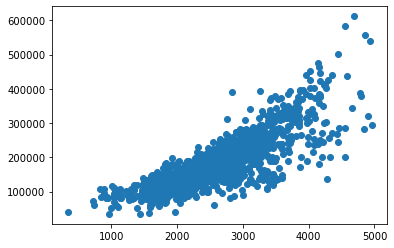

In [3]:
# plot price as a function of size

plt.scatter(data['TotalArea'], data['SalePrice'])

In [4]:
# target vector
y = data['SalePrice'].to_numpy()
m = len(data)
X = np.ones((len(data),2))
X[:,1] = data['TotalArea'].to_numpy()

In [5]:
theta = np.linalg.lstsq(X,y,rcond=None)[0]

In [6]:
theta

array([-30278.18262358,     82.39324266])

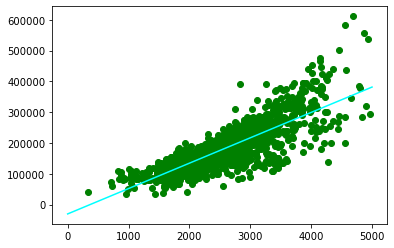

In [7]:
# plot data + line

plt.scatter(data['TotalArea'], data['SalePrice'],color='green')
m_plot = 100
x_plot = np.linspace(0,5000,m_plot)
y_plot = theta[0]+theta[1]*x_plot
plt.plot(x_plot,y_plot,color='cyan')

rcond = relative condition number of x (take M540)

In [8]:
# compute the (square root of the) mean squared error:
y_pred = X.dot(theta)
mse = np.mean((y-y_pred)**2)
np.sqrt(mse)

42741.29458002332

According to the MSE, your linear model is off by about 42k per prediction

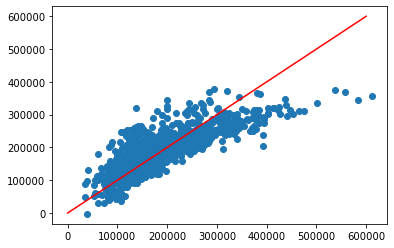

In [9]:
# plot y against y_pred
plt.scatter(y,y_pred)
plt.plot([0,600000],[0,600000],color='red')

****
1/24

## Example 2

**Goal**: predict price based on size and construction date

In [10]:
# feature matrix X

X = np.ones((m,3))
X[:,[1,2]] = data[['TotalArea','YearBuilt']].to_numpy()

In [11]:
theta = np.linalg.lstsq(X,y,rcond=None)[0]
theta

array([-1.39391802e+06,  7.21183228e+01,  7.05057412e+02])

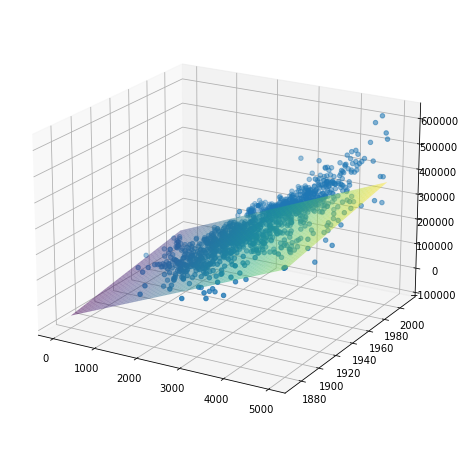

In [12]:
# plot data points + linear model (plane)

plt.figure(figsize=(8,8))
#create 3D axis
ax = plt.axes(projection = '3d')
# plot data points
ax.scatter(data['TotalArea'],data['YearBuilt'],data['SalePrice'])

#plot the plane

#z_plot = theta[0] +theta[1]*data['TotalArea'].to_numpy() +theta[2]*data['YearBuilt'].to_numpy()
#ax.plot_surface(data['TotalArea'],data['YearBuilt'],z_plot)
m_plot = 100
x_plot = np.linspace(0,5000,m_plot)
y_plot = np.linspace(1880,2000, m_plot)
X_plot,Y_plot = np.meshgrid(x_plot,y_plot)
Z_plot = theta[0] +theta[1]*X_plot +theta[2]*Y_plot
ax.plot_surface(X_plot,Y_plot,Z_plot,alpha=0.5,cmap = 'viridis')

ax.view_init(elev=20)

****

### Polynomial Features

Suppose we have data that seems to need a nonlinear fit.

We can fit something of the form (eg)

$$
y = \theta_0+\theta_1x+\theta_2x^2
$$

Where the feature matrix now looks like $X = [1|X|X^2]$

If there are $n$ features $x_0,\ldots,x_{n-1}$, how many polynomial features of degree $d$ are there?

>Combinations with replacement: Stars and Bars???

$\binom{n+d-1}{d!(n-1)!}$

## Example 3

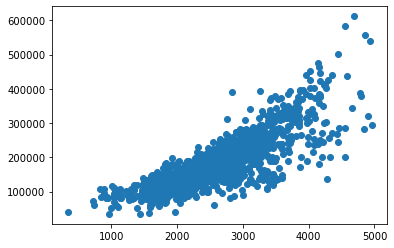

In [13]:
# plot price as a function of size

plt.scatter(data['TotalArea'], data['SalePrice'])

In [14]:
degree = 2
X = np.ones((m,degree+1))
x = data['TotalArea'].to_numpy()

for i in range(degree+1):
    X[:,i] = x**i
    
theta = np.linalg.lstsq(X,y,rcond = None)[0]
theta

array([5.36301099e+04, 1.50508363e+01, 1.24696039e-02])

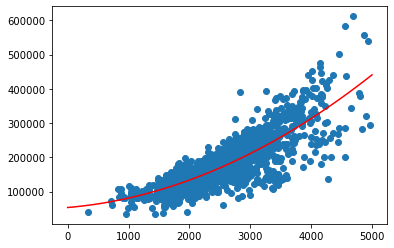

In [15]:
#plot the points

plt.scatter(data['TotalArea'], data['SalePrice'])

m_plot = 100
x_plot = np.linspace(0,5000,m_plot)
#y_plot = theta[0]+theta[1]*x_plot+theta[1]*x_plot**2

X_plot = np.ones((m_plot,degree+1))

for i in range(degree+1):
    X_plot[:,i] = x_plot**i
    
y_plot = X_plot.dot(theta)

plt.plot(x_plot,y_plot,color='red')

#### Javi_notes.txt

Go to 'polynomial regression' on Javi's github to find this content (and more!)

## Example 4: 2 features (size + year build + degree 2 polynomial features)

In [16]:
from itertools import combinations_with_replacement as combwr
from itertools import chain

In [23]:
degree = 3
n = 2 # number of features

combinations = combwr(range(n), degree)

for combination in combinations:
    print(combination)

(0, 0, 0)
(0, 0, 1)
(0, 1, 1)
(1, 1, 1)


In [24]:
# degree 0 + degree 1 + degree 2 + ...

combinations = chain.from_iterable(combwr(range(n), i) for i in range(degree + 1))

for combination in enumerate(combinations):
    print(combination)

(0, ())
(1, (0,))
(2, (1,))
(3, (0, 0))
(4, (0, 1))
(5, (1, 1))
(6, (0, 0, 0))
(7, (0, 0, 1))
(8, (0, 1, 1))
(9, (1, 1, 1))


In [28]:
# number of polynomial features
combinations = chain.from_iterable(combwr(range(n), i) for i in range(degree + 1))
sum(1 for combination in combinations)

10

In [30]:
def build_poly_features(X,degree=1):
    from itertools import combinations_with_replacement as combwr
    from itertools import chain
    
    # number of data points (rows), number of features (columns)
    
    try:
        m,n = X.shape # will not work when x is a vector
    except:
        m = len(X)
        n = 1
        X = X.reshape(m,1)
    
    # number of polynomial features
    
    combinations = chain.from_iterable(combwr(range(n), i) for i in range(degree + 1))
    n_poly = sum(1 for combination in combinations)
    
    # polynomial feature matrix
    combinations = chain.from_iterable(combwr(range(n), i) for i in range(degree + 1))
    X_poly = np.ones((m,n_poly))
    for column_index, combination in enumerate(combinations):
        X_poly[:,column_index] = np.product(X[:,combination],axis = 1)
        
    return X_poly

In [35]:
X = data[['TotalArea','YearBuilt']].to_numpy()

In [36]:
# polynomial feature matrix
X_poly = build_poly_features(X,degree=2)

# target vector y
y = data['SalePrice'].to_numpy()

#solve least squares probl
theta = np.linalg.lstsq(X_poly,y, rcond = None)[0]
theta[:,None]

array([[ 3.19496679e+07],
       [-7.22140116e+02],
       [-3.23065398e+04],
       [ 1.22694059e-02],
       [ 3.67484271e-01],
       [ 8.18665049e+00]])

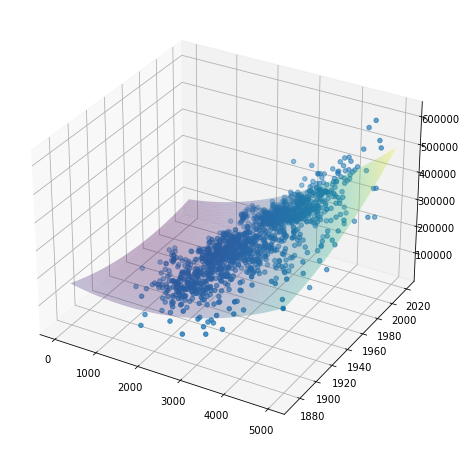

In [44]:
# extra: plot points + model
plt.figure(figsize=(8,8))
ax = plt.axes(projection='3d')

ax.scatter(data['TotalArea'],data['YearBuilt'],data['SalePrice'])

m_plot = 100
x_plot = np.linspace(0,5000,m_plot)
y_plot = np.linspace(1880,2020,m_plot)

X_plot,Y_plot = np.meshgrid(x_plot, y_plot)


#Z_plot = theta[0] theta[1]*x_plot + ...

X_flat = np.ones((m_plot**2,2))
X_flat[:,0] = X_plot.flatten()
X_flat[:,1] = Y_plot.flatten()
X_flat_poly = build_poly_features(X_flat,degree = 2)
Z_plot = X_flat_poly.dot(theta).reshape(m_plot,m_plot)

ax.plot_surface(X_plot,Y_plot,Z_plot,alpha=0.3,cmap='viridis')
